In [1]:
file_read = "007_fit_random"
file_write = "008_RMSE_random"

In [2]:
import polars as pl

df_train_val_preds = pl.read_parquet(f"{file_read}_train_val_preds.parquet")
df_test_preds = pl.read_parquet(f"{file_read}_test_preds.parquet")
df_coefs = pl.read_parquet(f"{file_read}_coefs.parquet")

In [3]:
column_target = "beta_av"
column_target_scaled = "beta_av_logit"
column_pred = f"{column_target}_pred"
column_pred_scaled = f"{column_target_scaled}_pred"

In [4]:
df_train_val_preds = df_train_val_preds.with_columns(
    (100 / (1 + (-pl.col(column_target_scaled)).exp())).alias(column_target),
    (100 / (1 + (-pl.col(column_pred_scaled)).exp())).alias(column_pred),
)

In [5]:
df_train_val_preds

pyridone_test,n_features,pyridone,backbone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,i64,f64,f64,f64,f64
0,51,1,0,0.161906,-0.266865,54.038835,43.367702
0,51,1,1,-1.585056,-0.156526,17.00806,46.094814
0,51,1,2,-0.148827,-0.20388,46.286168,44.920572
0,51,1,3,0.23845,-0.134025,55.933165,46.654382
0,51,1,4,-1.174656,-0.133465,23.601443,46.668323
…,…,…,…,…,…,…,…
12,5,11,3,-0.084269,-0.088697,47.894528,47.784018
12,5,11,4,-0.047133,-0.096303,48.821888,47.594295
12,5,11,5,0.577178,-0.043347,64.041771,48.916483


In [6]:
df_train_val_rmse = (
    df_train_val_preds
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [7]:
df_train_val_rmse

n_features,beta_av_rmse
i32,f64
51,11.082886
50,11.082824
49,11.082848
48,11.08281
47,11.082741
…,…
9,11.14142
8,11.143967
7,11.14519


In [8]:
df_train_val_rmse_min = df_train_val_rmse.filter(
    pl.col(f"{column_target}_rmse") == pl.col(f"{column_target}_rmse").min()
)

In [9]:
df_train_val_rmse_min

n_features,beta_av_rmse
i32,f64
44,11.082612


In [10]:
n_features_min = df_train_val_rmse_min["n_features"][0]

In [11]:
df_test_preds = df_test_preds.with_columns(
    (100 / (1 + (-pl.col(column_target_scaled)).exp())).alias(column_target),
    (100 / (1 + (-pl.col(column_pred_scaled)).exp())).alias(column_pred),
)

In [12]:
df_test_preds

pyridone_test,n_features,backbone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,f64,f64,f64,f64
0,51,0,-0.242775,-0.156845,43.960253,46.086903
0,51,1,-0.159524,-0.040088,46.020327,48.997936
0,51,2,-1.120282,-0.097984,24.595903,47.552363
0,51,3,-1.321297,-0.014168,21.060263,49.645808
0,51,4,-0.963822,-0.012835,27.611356,49.67913
…,…,…,…,…,…,…
12,5,3,-1.388052,-0.07068,19.97189,48.233745
12,5,4,-0.036604,-0.059353,49.085003,48.5166
12,5,5,0.175798,-0.038305,54.383662,49.042486


In [13]:
df_test_rmse = (
    df_test_preds
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [14]:
df_test_rmse

n_features,beta_av_rmse
i32,f64
51,12.426363
50,12.426692
49,12.426189
48,12.42622
47,12.426343
…,…
9,12.3854
8,12.390911
7,12.568847


In [15]:
df_test_rmse_min = df_test_rmse.filter(pl.col("n_features") == n_features_min)

In [16]:
df_test_rmse_min

n_features,beta_av_rmse
i32,f64
44,12.427309


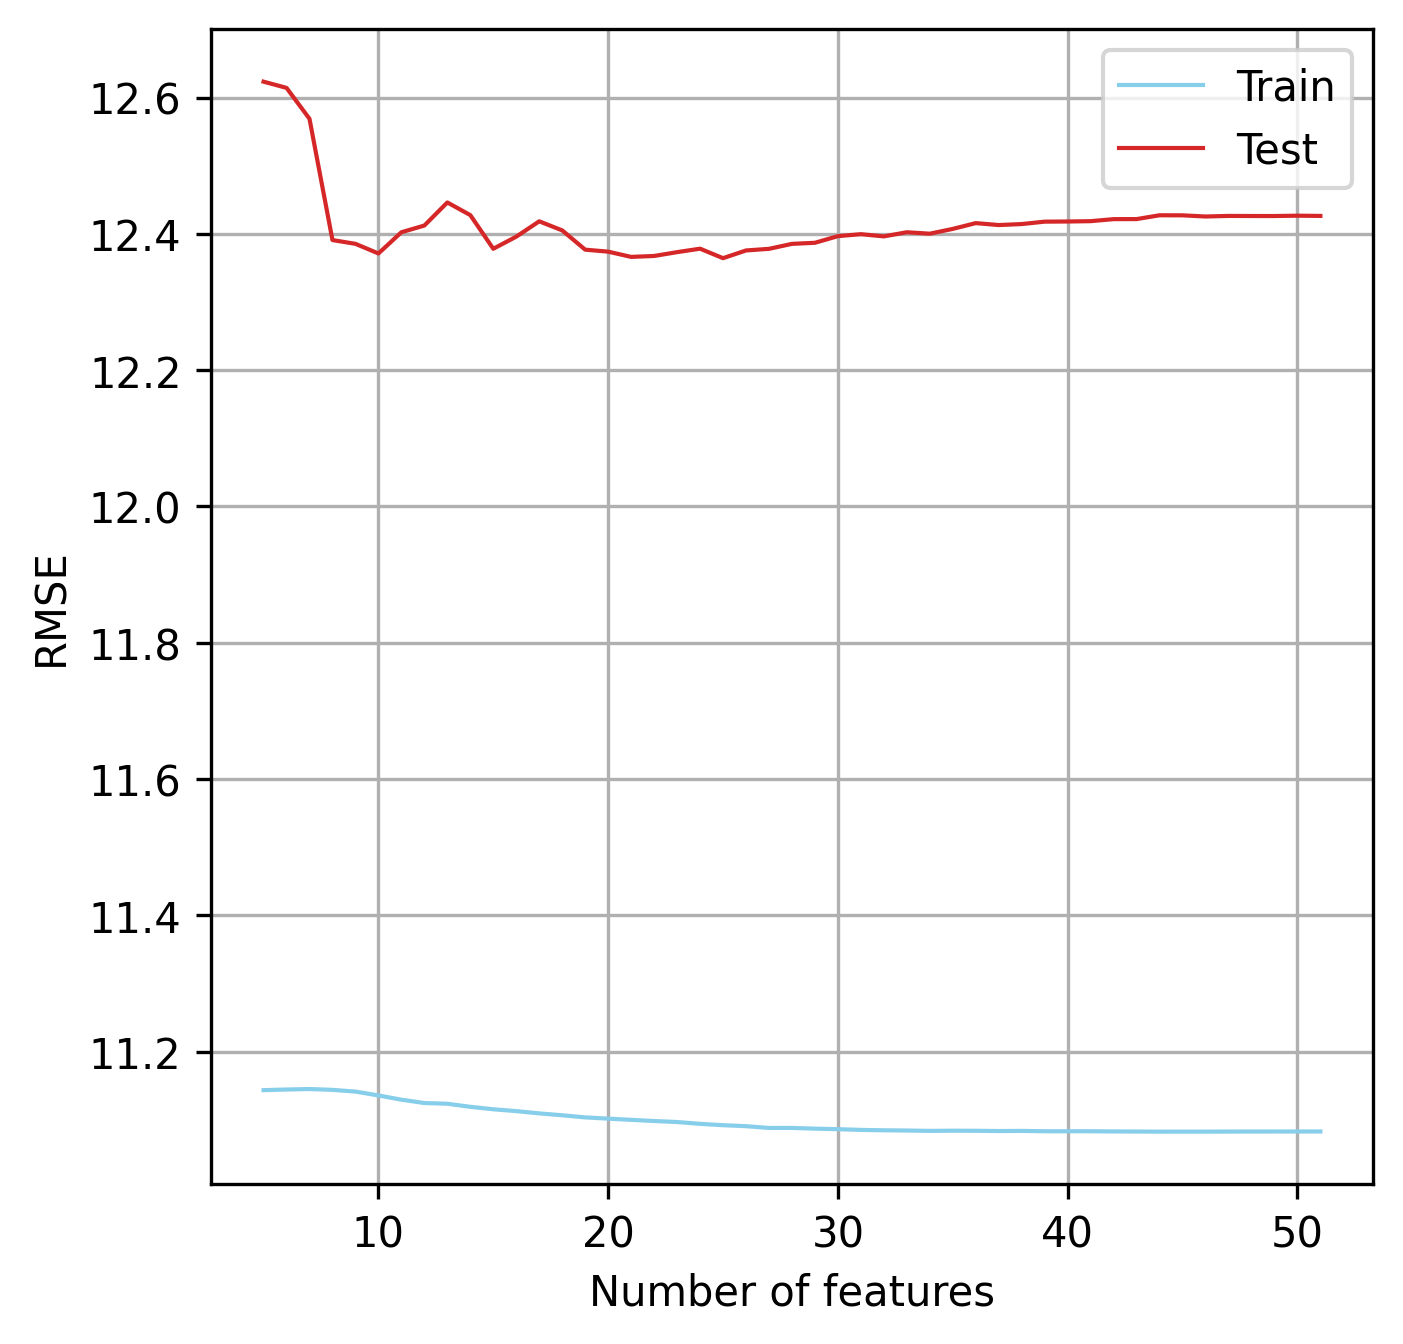

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(
    df_train_val_rmse["n_features"],
    df_train_val_rmse[f"{column_target}_rmse"],
    c="skyblue",
    label="Train",
    lw=1
)
ax.plot(
    df_test_rmse["n_features"],
    df_test_rmse[f"{column_target}_rmse"],
    c="tab:red",
    label="Test",
    lw=1
)

ax.set_xlabel("Number of features")
ax.set_ylabel("RMSE")

ax.grid()
ax.legend()

plt.savefig(
    f"{file_write}_plot.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [18]:
df_train_val_min = df_train_val_preds.filter(pl.col("n_features") == n_features_min)

In [19]:
df_train_val_min

pyridone_test,n_features,pyridone,backbone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,i64,f64,f64,f64,f64
0,44,1,0,0.161906,-0.26668,54.038835,43.37223
0,44,1,1,-1.585056,-0.155749,17.00806,46.114129
0,44,1,2,-0.148827,-0.204385,46.286168,44.908097
0,44,1,3,0.23845,-0.133289,55.933165,46.672692
0,44,1,4,-1.174656,-0.132942,23.601443,46.681332
…,…,…,…,…,…,…,…
12,44,11,3,-0.084269,-0.065133,47.894528,48.372243
12,44,11,4,-0.047133,-0.080781,48.821888,47.981563
12,44,11,5,0.577178,0.02107,64.041771,50.526741


In [20]:
df_test_min = df_test_preds.filter(pl.col("n_features") == n_features_min)

In [21]:
df_test_min

pyridone_test,n_features,backbone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,f64,f64,f64,f64
0,44,0,-0.242775,-0.156264,43.960253,46.101341
0,44,1,-0.159524,-0.039211,46.020327,49.019859
0,44,2,-1.120282,-0.098307,24.595903,47.544301
0,44,3,-1.321297,-0.013258,21.060263,49.668561
0,44,4,-0.963822,-0.012136,27.611356,49.696599
…,…,…,…,…,…,…
12,44,3,-1.388052,-0.074935,19.97189,48.127495
12,44,4,-0.036604,-0.08091,49.085003,47.978361
12,44,5,0.175798,-0.007728,54.383662,49.806805


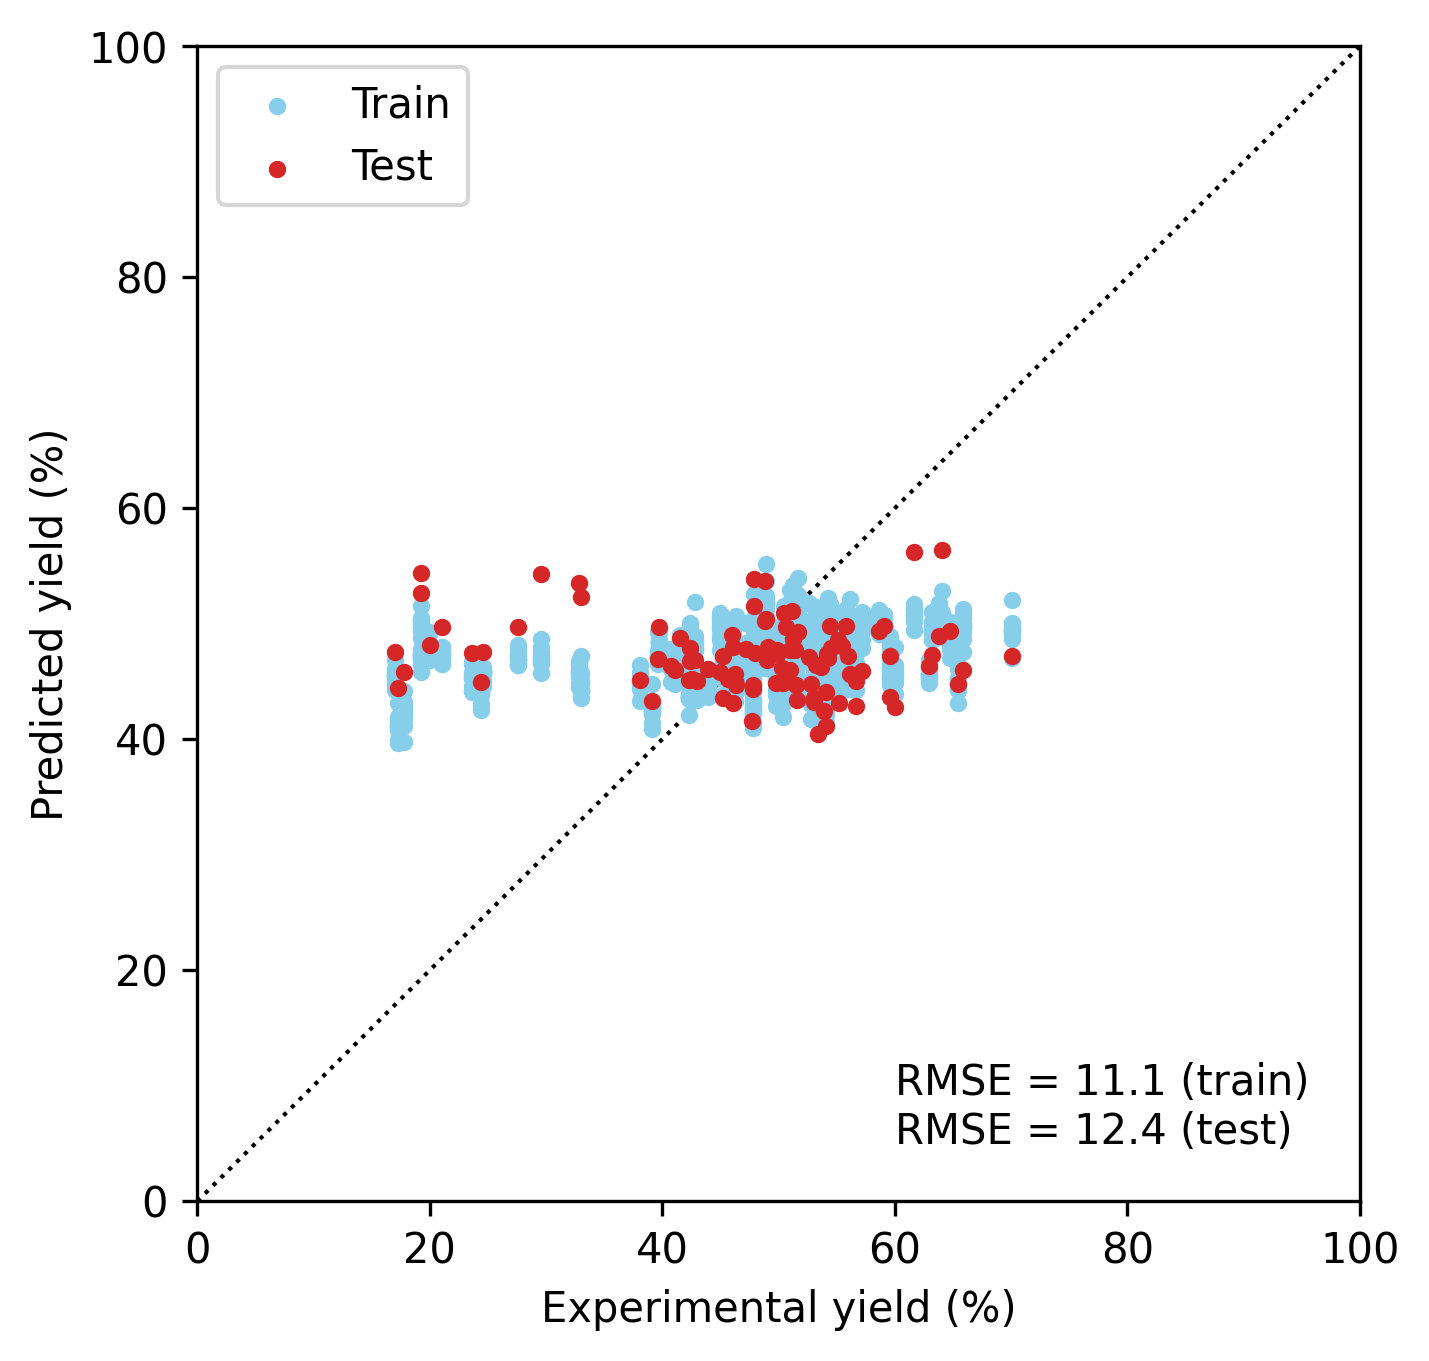

In [22]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(
    [0, 100],
    [0, 100],
    c="black",
    linestyle="dotted",
    lw=1,
    zorder=0
)
ax.scatter(
    df_train_val_min[column_target],
    df_train_val_min[column_pred],
    c="skyblue",
    label="Train",
    s=10,
    zorder=1
)
ax.scatter(
    df_test_min[column_target],
    df_test_min[column_pred],
    c="tab:red",
    label="Test",
    s=10,
    zorder=2
)

ax.set_xlabel("Experimental yield (%)")
ax.set_ylabel("Predicted yield (%)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

ax.legend()
ax.text(
    0.60, 0.05,
    f"RMSE = {df_train_val_rmse_min[f'{column_target}_rmse'][0]:1.1f} (train)\n"
    f"RMSE = {df_test_rmse_min[f'{column_target}_rmse'][0]:1.1f} (test)",
    transform=ax.transAxes
)

plt.savefig(
    f"{file_write}_scatter_all.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [23]:
column_group = "pyridone"

In [24]:
groups_test = df_test_preds[f"{column_group}_test"].unique(maintain_order=True)

In [25]:
groups_test

pyridone_test
i32
0
1
2
3
4
…
8
9
10


In [26]:
df_train_val_min

pyridone_test,n_features,pyridone,backbone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,i64,f64,f64,f64,f64
0,44,1,0,0.161906,-0.26668,54.038835,43.37223
0,44,1,1,-1.585056,-0.155749,17.00806,46.114129
0,44,1,2,-0.148827,-0.204385,46.286168,44.908097
0,44,1,3,0.23845,-0.133289,55.933165,46.672692
0,44,1,4,-1.174656,-0.132942,23.601443,46.681332
…,…,…,…,…,…,…,…
12,44,11,3,-0.084269,-0.065133,47.894528,48.372243
12,44,11,4,-0.047133,-0.080781,48.821888,47.981563
12,44,11,5,0.577178,0.02107,64.041771,50.526741


In [27]:
df_train_val_min_rmse = (
    df_train_val_min
    .group_by(f"{column_group}_test", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [28]:
df_train_val_min_rmse

pyridone_test,beta_av_rmse
i32,f64
0,10.768708
1,10.731059
2,11.09602
3,10.762469
4,11.131928
…,…
8,11.330373
9,11.363879
10,11.307226


In [29]:
df_test_min_rmse = (
    df_test_min
    .group_by(f"{column_group}_test", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [30]:
df_test_min_rmse

pyridone_test,beta_av_rmse
i32,f64
0,15.419998
1,15.535416
2,11.657462
3,15.52233
4,12.309624
…,…
8,9.627099
9,9.324846
10,9.635069


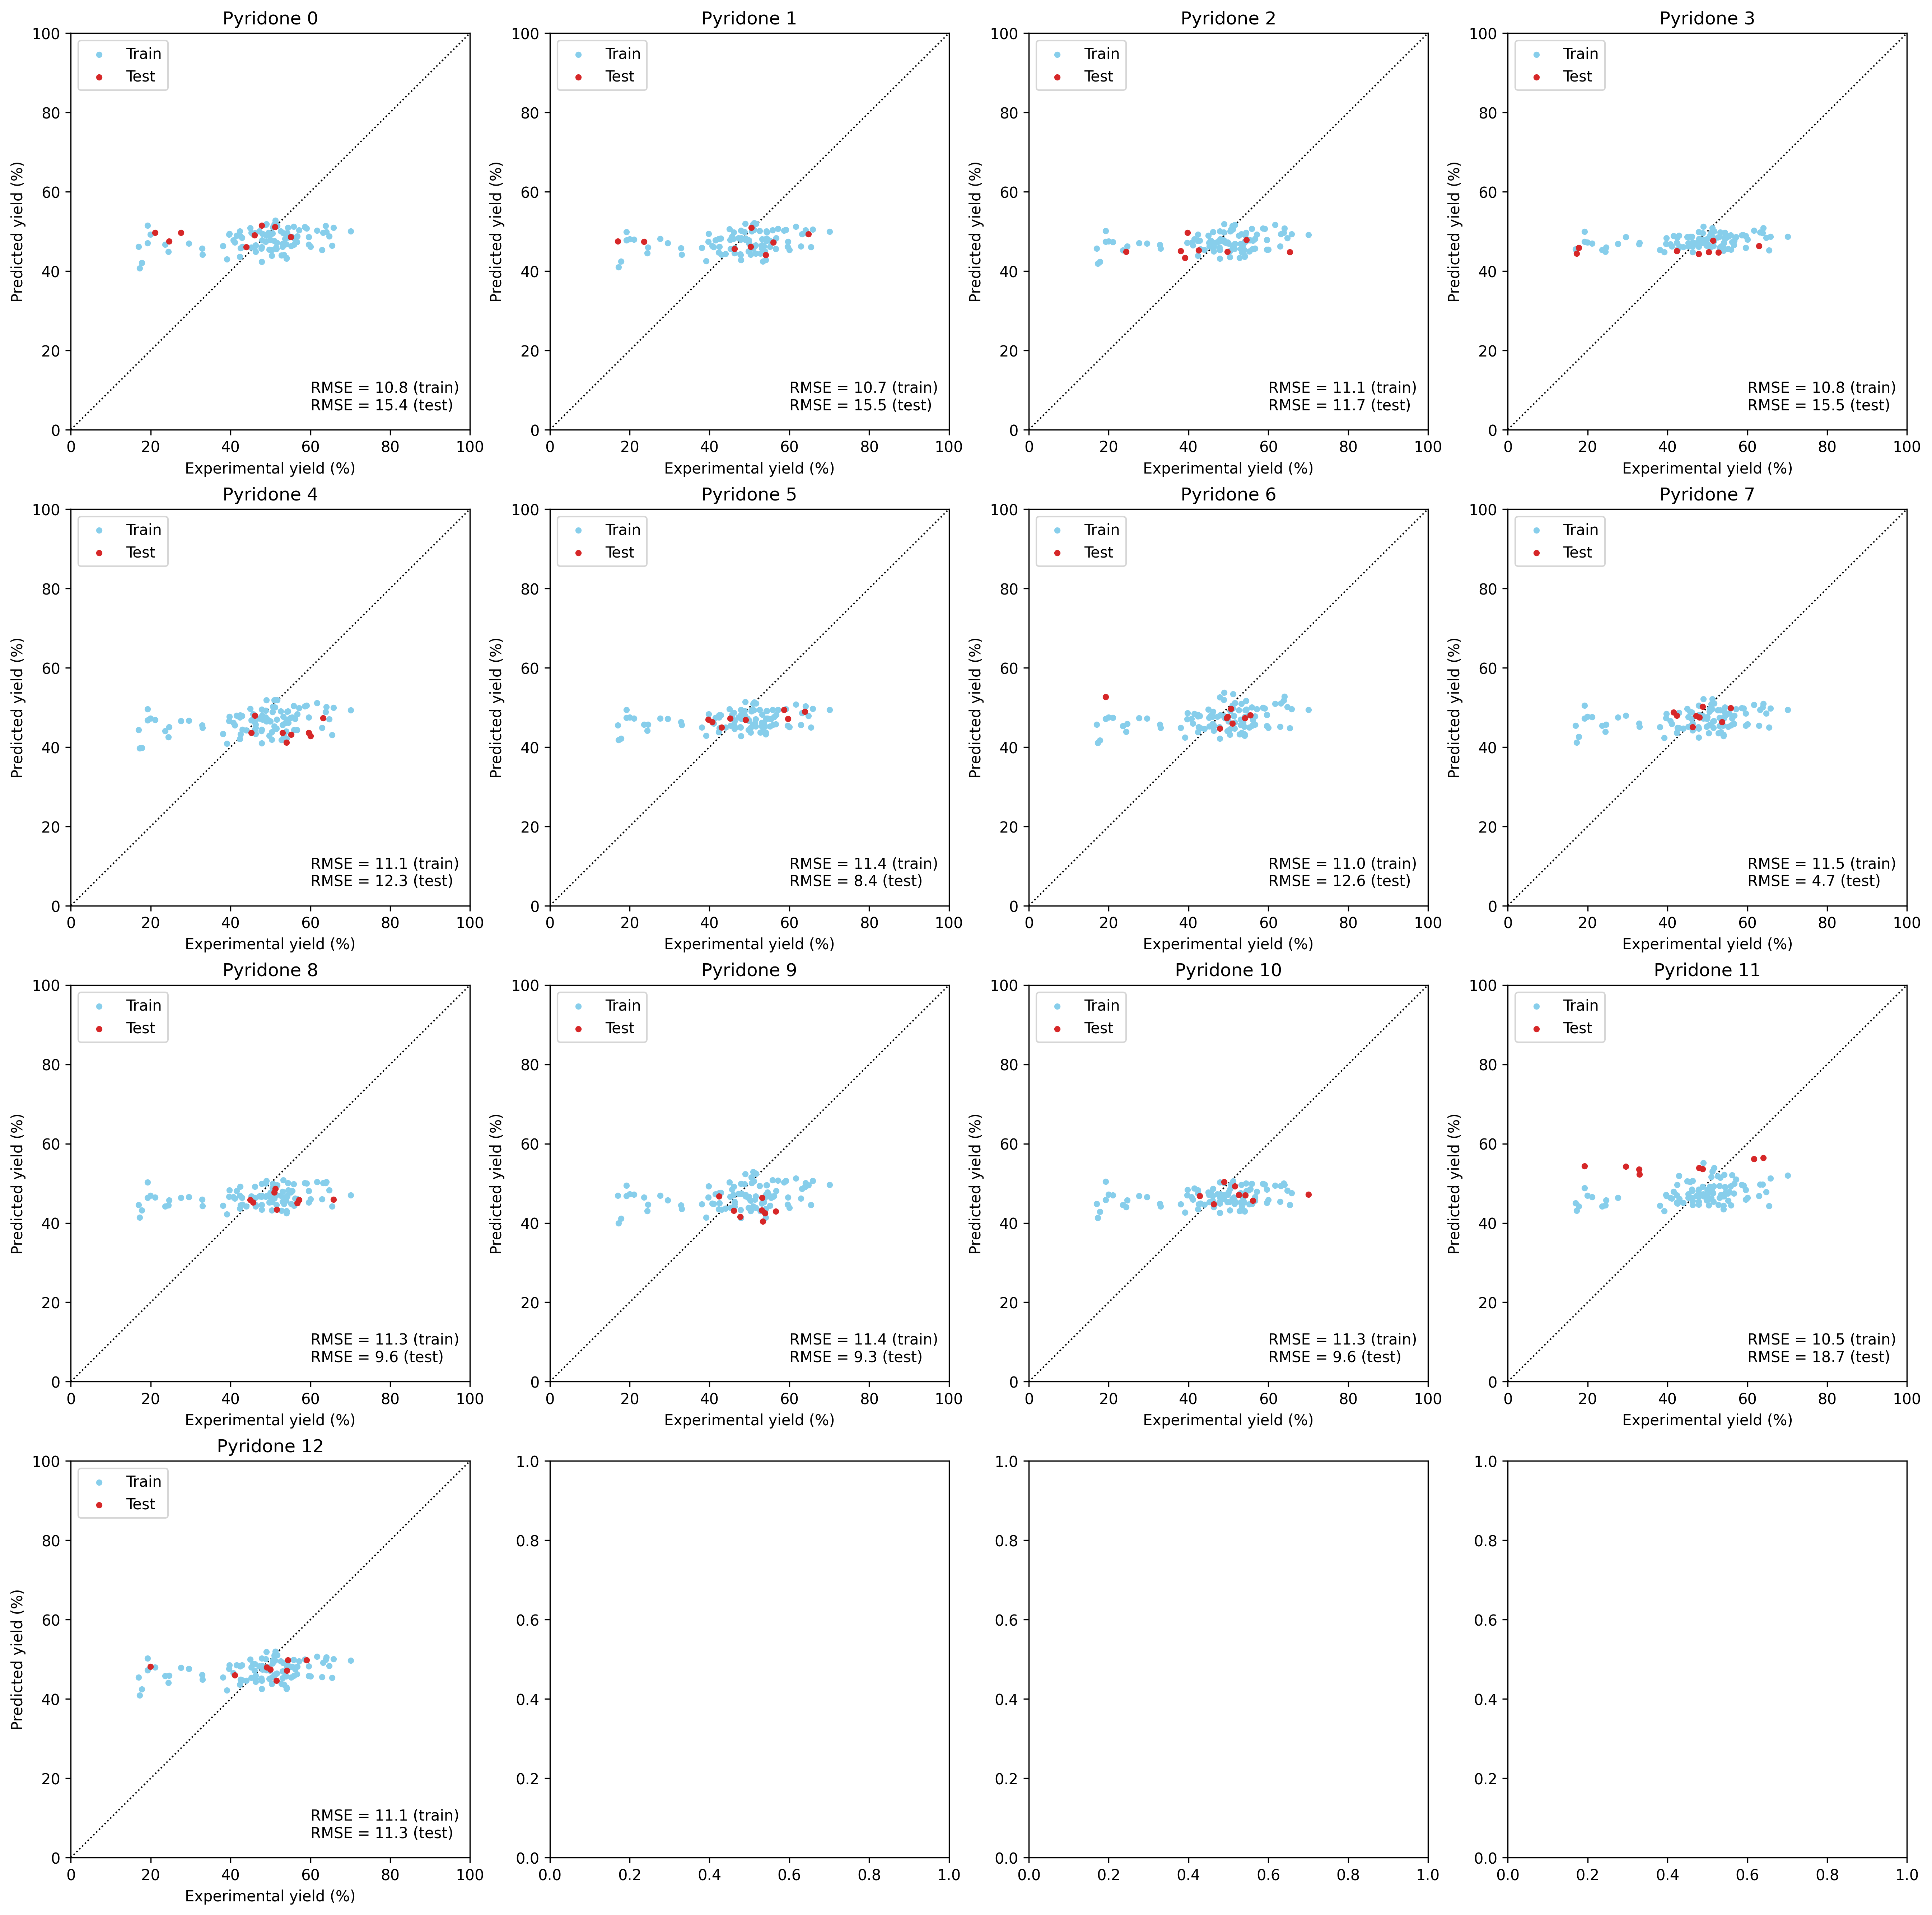

In [31]:
fig, axes = plt.subplots(4, 4, figsize=(22, 22), dpi=300)

for group_test in groups_test:
    df_train_val_min_ = df_train_val_min.filter(pl.col(f'{column_group}_test') == group_test)
    df_test_min_ = df_test_min.filter(pl.col(f'{column_group}_test') == group_test)
    df_train_val_min_rmse_ = df_train_val_min_rmse.filter(pl.col(f'{column_group}_test') == group_test)
    df_test_min_rmse_ = df_test_min_rmse.filter(pl.col(f'{column_group}_test') == group_test)
    
    div, mod = divmod(group_test, 4)
    
    axes[div, mod].plot(
        [0, 100],
        [0, 100],
        c="black",
        linestyle="dotted",
        lw=1,
        zorder=0
    )
    axes[div, mod].scatter(
        df_train_val_min_[column_target],
        df_train_val_min_[column_pred],
        c="skyblue",
        s=10,
        label="Train",
        zorder=1
    )
    axes[div, mod].scatter(
        df_test_min_[column_target],
        df_test_min_[column_pred],
        c="tab:red",
        s=10,
        label="Test",
        zorder=2
    )
    
    axes[div, mod].set_title(f"Pyridone {group_test}")
    axes[div, mod].set_xlabel("Experimental yield (%)")
    axes[div, mod].set_ylabel("Predicted yield (%)")
    axes[div, mod].set_xlim(0, 100)
    axes[div, mod].set_ylim(0, 100)
    
    axes[div, mod].legend()
    axes[div, mod].text(
        0.60, 0.05,
        f"RMSE = {df_train_val_min_rmse_[f'{column_target}_rmse'][0]:1.1f} (train)\n"
        f"RMSE = {df_test_min_rmse_[f'{column_target}_rmse'][0]:1.1f} (test)",
        transform=axes[div, mod].transAxes
    )
    
plt.savefig(
    f"{file_write}_scatter_each.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()